In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from datetime import datetime

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='muted')

print(f'Notebook run: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Notebook run: 2026-06-03 16:53:04


---
## Step 1 — Interest Rate Curve (SOFR / OIS)

The risk-free rate is bootstrapped from the SOFR/OIS curve (FRED public API, no key required).  
Each contract is discounted at its **own maturity-matched rate** — consistent with how derivatives desks price USD options post-LIBOR transition (June 2023).

In [2]:
from config.market_config import get_ois_curve, interpolate_rate, curve_summary, maturity_label

print('Fetching SOFR/OIS curve from FRED...')
rate_curve = get_ois_curve(force_refresh=True)
R = interpolate_rate(rate_curve, 0.25)   # 3M SOFR — representative scalar

print()
print('SOFR / OIS Discount Curve')
print('─' * 40)
print(f'  {"Tenor":<8} {"T (yrs)":<10} {"Rate":>7}')
print('─' * 40)
for T, r in sorted(rate_curve.items()):
    print(f'  {maturity_label(T):<8} {T:<10.4f} {r*100:>6.3f}%')
print('─' * 40)
print(f'\nRepresentative 3M SOFR (R): {R*100:.3f}%')

Fetching SOFR/OIS curve from FRED...

SOFR / OIS Discount Curve
────────────────────────────────────────
  Tenor    T (yrs)       Rate
────────────────────────────────────────
  O/N      0.0027      3.630%
  3M       0.2500      3.623%
  5Y       5.0000      4.214%
  10Y      10.0000     4.491%
────────────────────────────────────────

Representative 3M SOFR (R): 3.623%


---
## Step 2 — Fetch NVDA Option Chain

In [64]:
TICKER = 'NVDA'

from data.market_data import get_all_options

print(f'Fetching live option chain for {TICKER}...')
raw_df = get_all_options(TICKER)

SPOT = raw_df['spot'].iloc[0]

# ── Instrument classification (drives dividend method + exercise style) ──────
# data/instrument_classifier.py buckets the ticker into EQUITY / ETF / INDEX,
# which decides whether dividends are discrete-cash (American exercise) or a
# continuous index yield (European). Stamped per-row by get_all_options().
INSTRUMENT_TYPE = raw_df['instrument_type'].iloc[0] if 'instrument_type' in raw_df.columns else 'EQUITY'
EXERCISE_STYLE  = raw_df['ExerciseStyle'].iloc[0]   if 'ExerciseStyle'   in raw_df.columns else 'american'

# ── Dividend yield is now PER-EXPIRY, not a single yfinance scalar ───────────
# For each expiry the implied forward F(T) is recovered from put-call parity
# (data/forward_curve.py); q_implied(T) = r(T) - ln(F/S)/T. Where the chain is
# too thin to fit, we fall back to a trailing-12M realised yield. The old
# broken yfinance info['dividendYield'] (the 47% garbage) is no longer used.
q_by_expiry = (
    raw_df.groupby('maturity')['dividend_yield'].first()
    if 'dividend_yield' in raw_df.columns else pd.Series(dtype=float)
)
# Representative scalar for downstream display only — real values are per-row in df["q"].
Q = float(np.nanmedian(q_by_expiry.values)) if len(q_by_expiry) else 0.0

src_counts = (
    raw_df.drop_duplicates('maturity')['dividend_source'].value_counts().to_dict()
    if 'dividend_source' in raw_df.columns else {}
)

print()
print(f'  {"Ticker":<28}: {TICKER}')
print(f'  {"Instrument type":<28}: {INSTRUMENT_TYPE}')
print(f'  {"Exercise style":<28}: {EXERCISE_STYLE.capitalize()}')
print(f'  {"Spot price":<28}: ${SPOT:.2f}')
print(f'  {"Maturities":<28}: {raw_df["maturity"].nunique()}')
print(f'  {"Raw contracts":<28}: {len(raw_df):,}')
print(f'  {"  Calls":<28}: {(raw_df.type=="call").sum():,}')
print(f'  {"  Puts":<28}: {(raw_df.type=="put").sum():,}')
print()
print('  Rates and dividend yields (stamped per-row before pricing):')
print(f'  {"  3M SOFR R (display)":<28}: {R*100:.3f}%')
if len(q_by_expiry):
    print(f'  {"  q median (display)":<28}: {Q*100:.4f}%   (per-expiry implied — breakdown below)')
    print(f'  {"  q range":<28}: {np.nanmin(q_by_expiry.values)*100:.4f}% – {np.nanmax(q_by_expiry.values)*100:.4f}%')
    print(f'  {"  q source mix":<28}: ' + ', '.join(f'{k}×{v}' for k, v in src_counts.items()))


Fetching live option chain for NVDA...

  Ticker                      : NVDA
  Instrument type             : EQUITY
  Exercise style              : American
  Spot price                  : $224.36
  Maturities                  : 23
  Raw contracts               : 4,253
    Calls                     : 2,262
    Puts                      : 1,991

  Rates and dividend yields (stamped per-row before pricing):
    3M SOFR R (display)       : 3.642%
    q median (display)        : 0.6230%   (per-expiry implied — breakdown below)
    q range                   : 0.1076% – 9.6506%
    q source mix              : implied_forward×23


In [65]:
# Each expiry gets a maturity-matched SOFR rate AND its own implied dividend
# yield q(T) backed out from the forward F(T) (put-call parity). The "source"
# column shows whether q came from the implied forward or the trailing fallback.
has_fwd = 'forward' in raw_df.columns
has_src = 'dividend_source' in raw_df.columns

print(f'  {"Expiry":<13} {"T":>6}  {"r(T)":>7}  {"q(T)":>8}  {"F(T)":>9}  {"source":>16}  {"N":>5}')
print('  ' + '─' * 74)
for mat in sorted(raw_df['maturity'].unique()):
    grp = raw_df[raw_df['maturity'] == mat]
    T   = grp['T'].iloc[0]
    r_t = interpolate_rate(rate_curve, T)
    q_t = float(grp['dividend_yield'].iloc[0]) if 'dividend_yield' in grp.columns else 0.0
    f_t = float(grp['forward'].iloc[0]) if has_fwd and pd.notna(grp['forward'].iloc[0]) else np.nan
    src = grp['dividend_source'].iloc[0] if has_src else '—'
    f_str = f'{f_t:>9.2f}' if np.isfinite(f_t) else f'{"—":>9}'
    print(f'  {str(mat):<13} {T:>6.3f}  {r_t*100:>6.3f}%  {q_t*100:>7.4f}%  {f_str}  {str(src):>16}  {len(grp):>5,}')


  Expiry             T     r(T)      q(T)       F(T)            source      N
  ──────────────────────────────────────────────────────────────────────────
  2026-06-03     0.003   3.624%   4.2837%     224.36   implied_forward     87
  2026-06-05     0.009   3.602%   9.6506%     224.24   implied_forward    177
  2026-06-08     0.017   3.596%   6.8953%     224.23   implied_forward     80
  2026-06-10     0.022   3.594%   6.4719%     224.22   implied_forward     79
  2026-06-12     0.028   3.593%   4.0512%     224.33   implied_forward    146
  2026-06-18     0.044   3.591%   1.9627%     224.52   implied_forward    775
  2026-06-26     0.066   3.591%   1.5043%     224.67   implied_forward    112
  2026-07-02     0.083   3.591%   1.0556%     224.83   implied_forward     87
  2026-07-10     0.105   3.606%   0.6336%     225.06   implied_forward     59
  2026-07-17     0.124   3.616%   0.4969%     225.23   implied_forward    149
  2026-08-21     0.220   3.637%   0.1076%     226.11   implied_fo

---
## Step 3 — Apply Liquidity Filters

Keep contracts where:
- Bid-ask spread ≤ 5% of mid-price
- Moneyness K/S ∈ [0.80, 1.20]
- Volume ≥ 100
- Open interest ≥ 1,000
- No static arbitrage violations (calendar, butterfly)

In [66]:
from services.market_service import filter_chain_with_stats

filtered_df, filter_stats = filter_chain_with_stats(
    raw_df,
    spread_limit      = 0.05,
    rate_curve        = rate_curve,
    min_volume        = 100,
    min_open_interest = 1000,
    moneyness_lo      = 0.8,
    moneyness_hi      = 1.2,
)

n_raw, n_filt = len(raw_df), len(filtered_df)
print(f'Contracts: {n_raw:,} → {n_filt:,}  (kept {n_filt/n_raw*100:.1f}%)')
print(f'  Calls    : {(filtered_df.type=="call").sum():,}')
print(f'  Puts     : {(filtered_df.type=="put").sum():,}')
print(f'  Expiries : {filtered_df["maturity"].nunique()}')
print()
print('Per-row rate / yield columns stamped by filter_chain_with_stats:')
print(f'  df["r"] present : {"r" in filtered_df.columns}  '
      f'(range {filtered_df["r"].min()*100:.3f}% – {filtered_df["r"].max()*100:.3f}%)')
print(f'  df["q"] present : {"q" in filtered_df.columns}  '
      f'(values: {dict(filtered_df.groupby("ticker")["q"].first().map(lambda v: f"{v*100:.4f}%"))})')
print()
print(f'  {"Filter":<40} {"Dropped":>8}  {"% raw":>7}')
print('  ' + '─' * 60)
for reason, count in filter_stats.items():
    print(f'  {reason:<40} {count:>8,}  {count/n_raw*100:>6.1f}%')


Contracts: 4,253 → 460  (kept 10.8%)
  Calls    : 302
  Puts     : 158
  Expiries : 23

Per-row rate / yield columns stamped by filter_chain_with_stats:
  df["r"] present : True  (range 3.591% – 4.134%)
  df["q"] present : True  (values: {'NVDA': '4.2837%'})

  Filter                                    Dropped    % raw
  ────────────────────────────────────────────────────────────
  Rel. spread ≥ 5%                            1,259    29.6%
  Moneyness outside [0.8, 1.2]                2,078    48.9%
  Arbitrage violation                             2     0.0%
  Volume < 100                                  368     8.7%
  Open interest < 1000                           86     2.0%


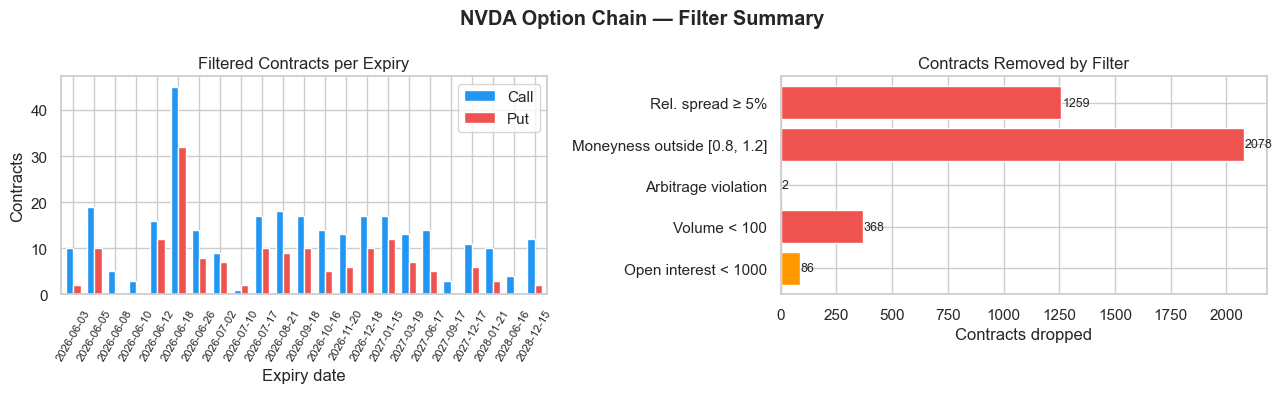

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'NVDA Option Chain — Filter Summary', fontweight='bold')

# Contracts per expiry (calls vs puts)
mat_counts = filtered_df.groupby(['maturity', 'type']).size().unstack(fill_value=0)
mat_counts.plot(kind='bar', ax=axes[0], color=['#2196F3', '#EF5350'], width=0.7, edgecolor='white')
axes[0].set_title('Filtered Contracts per Expiry')
axes[0].set_xlabel('Expiry date')
axes[0].set_ylabel('Contracts')
axes[0].tick_params(axis='x', rotation=60, labelsize=8)
axes[0].legend(['Call', 'Put'])

# Filter waterfall
reasons = list(filter_stats.keys())
counts  = list(filter_stats.values())
colors  = ['#EF5350' if c > 300 else '#FF9800' if c > 50 else '#66BB6A' for c in counts]
axes[1].barh(reasons[::-1], counts[::-1], color=colors[::-1], edgecolor='white')
axes[1].set_title('Contracts Removed by Filter')
axes[1].set_xlabel('Contracts dropped')
for i, v in enumerate(counts[::-1]):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('filter_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 4 — Calibrate Heston Model

Two **independent** calibrations (no warm start between them):
1. **European proxy** (~4 s) — analytical characteristic function (Cui et al. 2016 LM solver), European pricing. Standalone reference fit.
2. **PDE / C++ MCS ADI** (~25–90 s) — proper American early-exercise via Modified Craig–Sneyd ADI, unconditionally stable C++ backend.

Each calibrates from the **same default initial guess** and uses **maturity-matched SOFR/OIS rates** (not a flat scalar R). **Pricing uses the PDE-calibrated parameters.**

In [68]:
from services.calibration_service import calibrate_option_chain
from services.pricing_service import HestonParameters

print('European-proxy calibration (analytic, standalone reference)...')
res_eu, _ = calibrate_option_chain(
    filtered_df,
    rate_curve=rate_curve,
    american_method='european_proxy',
)
p_eu = res_eu.params
feller_eu = 2*p_eu.kappa*p_eu.theta - p_eu.sigma**2
print(f'  Done in {res_eu.runtime_seconds:.1f}s  |  Loss: {res_eu.loss:.4e}')
print(f'  v₀={p_eu.v0:.4f}  κ={p_eu.kappa:.4f}  θ={p_eu.theta:.4f}  σ={p_eu.sigma:.4f}  ρ={p_eu.rho:.4f}')
print(f'  Feller: {feller_eu:+.4f}  ({"✓" if feller_eu > 0 else "✗"})')

European-proxy calibration (analytic, standalone reference)...
  Done in 5.2s  |  Loss: 4.7222e+01
  v₀=0.1869  κ=7.1144  θ=0.2152  σ=1.0000  ρ=-0.1043
  Feller: +2.0617  (✓)


In [69]:
Ns, Nv, Nt = 40, 20, 40

print('PDE calibration (C++ MCS ADI backend) — independent, no warm start...')
print(f'  Contracts     : {len(filtered_df):,}  |  PDE grid: Ns={Ns} Nv={Nv} Nt={Nt}')
print(f'  Initial guess : default (NOT warm-started from the EU proxy)')
print()

# Independent PDE calibration: omitting initial_guess uses DEFAULT_INITIAL_GUESS,
# so this fit does not depend on the European-proxy result above.
res_pde, cal_df = calibrate_option_chain(
    filtered_df,
    rate_curve=rate_curve,
    american_method='pde',
    Ns=Ns, Nv=Nv, Nt=Nt,
)
p   = res_pde.params
feller = 2*p.kappa*p.theta - p.sigma**2

print(f'Calibration complete in {res_pde.runtime_seconds:.1f}s')
print()
print(f'  {"Parameter":<28} {"PDE (final)":>12}')
print(f'  {"─"*42}')
for name, v_pde in [
    ('v₀  (initial variance)',  p.v0),
    ('κ   (mean-reversion)',    p.kappa),
    ('θ̄   (long-run variance)', p.theta),
    ('σ   (vol of vol)',        p.sigma),
    ('ρ   (spot-vol corr)',     p.rho),
]:
    print(f'  {name:<28} {v_pde:>12.6f}')
print(f'  {"─"*42}')
print(f'  {"Loss":<28} {res_pde.loss:>12.4e}')
print()
print(f'  Feller 2κθ−σ²  : {feller:+.4f}  ({"satisfied ✓" if feller > 0 else "VIOLATED ✗"})')
print(f'  Init vol        : {p.v0**0.5*100:.1f}%')
print(f'  Long-run vol    : {p.theta**0.5*100:.1f}%')

PDE calibration (C++ MCS ADI backend) — independent, no warm start...
  Contracts     : 460  |  PDE grid: Ns=40 Nv=20 Nt=40
  Initial guess : default (NOT warm-started from the EU proxy)

Calibration complete in 103.0s

  Parameter                     PDE (final)
  ──────────────────────────────────────────
  v₀  (initial variance)           0.200991
  κ   (mean-reversion)             6.535006
  θ̄   (long-run variance)         0.210690
  σ   (vol of vol)                 1.000000
  ρ   (spot-vol corr)             -0.033804
  ──────────────────────────────────────────
  Loss                           7.4068e+01

  Feller 2κθ−σ²  : +1.7537  (satisfied ✓)
  Init vol        : 44.8%
  Long-run vol    : 45.9%


---
## Step 5 — Price All Contracts

Price every filtered contract using the PDE-calibrated Heston parameters.  
Each contract uses its own maturity-matched SOFR/OIS rate from the curve.

In [70]:
from services.pricing_service import price_option_frame

print(f'Pricing {len(filtered_df):,} contracts (PDE / C++ backend, maturity-matched rates)...')
prices = price_option_frame(
    filtered_df,
    rate_curve=rate_curve,
    heston_params=res_pde,
    Ns=Ns, Nv=Nv, Nt=Nt,
    american_method='pde',
)

print(f'  Priced OK : {prices.notna().sum():,}')
print(f'  Failed    : {prices.isna().sum():,}')
print(f'  Range     : ${prices.dropna().min():.4f} – ${prices.dropna().max():.4f}')

Pricing 460 contracts (PDE / C++ backend, maturity-matched rates)...
  Priced OK : 460
  Failed    : 0
  Range     : $0.1599 – $80.6625


---
## Step 6 — Validate Prices

Sanity checks applied before accepting results:
1. All prices ≥ 0
2. All prices ≥ intrinsic value (no early-exercise arbitrage)
3. No blown-up values (|price| > $1,000,000)
4. Compare to market mid-price (MAE, relative error, bid-ask coverage)

In [71]:
df = filtered_df.copy()
df['model_price'] = prices

# ── basic checks ──────────────────────────────────────────────────────────
assert (df['model_price'].dropna() >= 0).all(), 'FAIL: negative prices'
print('✓  All prices non-negative')

df['intrinsic'] = np.where(
    df['type'] == 'call',
    np.maximum(df['spot'] - df['strike'], 0.0),
    np.maximum(df['strike'] - df['spot'], 0.0),
)
violations = df[df['model_price'] < df['intrinsic'] - 0.01]
print(f'✓  Intrinsic violations : {len(violations)}')

blown = df[df['model_price'].abs() > 1e6]
print(f'✓  Blown-up contracts   : {len(blown)}')

# ── price accuracy ────────────────────────────────────────────────────────
df['price_error']   = df['model_price'] - df['mid_price']
df['abs_error']     = df['price_error'].abs()
df['rel_error']     = df['price_error'] / df['mid_price']
df['within_spread'] = (df['model_price'] >= df['bid']) & (df['model_price'] <= df['ask'])

print()
print('Pricing accuracy:')
print(f'  MAE                   : ${df["abs_error"].mean():.4f}')
print(f'  Median abs error      : ${df["abs_error"].median():.4f}')
print(f'  Mean relative error   : {df["rel_error"].abs().mean()*100:.2f}%')
print(f'  Within bid-ask spread : {df["within_spread"].sum()} / {len(df)}  ({df["within_spread"].mean()*100:.1f}%)')

✓  All prices non-negative
✓  Intrinsic violations : 0
✓  Blown-up contracts   : 0

Pricing accuracy:
  MAE                   : $0.3899
  Median abs error      : $0.2694
  Mean relative error   : 5.98%
  Within bid-ask spread : 129 / 460  (28.0%)


In [72]:
from calibration.implied_vol import implied_volatility

def row_iv(row, price_col):
    price = row.get(price_col)
    if pd.isna(price) or price <= 0:
        return np.nan
    try:
        return implied_volatility(
            price, row['spot'], row['strike'],
            float(row.get('r', R)),   # per-row SOFR rate from df["r"]
            row['T'], row['type'],
            float(row.get('q', 0.0)), # per-row dividend yield from df["q"]
        )
    except Exception:
        return np.nan

df['market_iv'] = df.apply(row_iv, axis=1, args=('mid_price',))
df['model_iv']  = df.apply(row_iv, axis=1, args=('model_price',))
df['iv_error']  = df['model_iv'] - df['market_iv']

print('Implied Volatility accuracy:')
print(f'  Market IV  — mean: {df["market_iv"].mean()*100:.1f}%   std: {df["market_iv"].std()*100:.1f}%')
print(f'  Model  IV  — mean: {df["model_iv"].mean()*100:.1f}%   std: {df["model_iv"].std()*100:.1f}%')
print()
print(f'  Mean |IV error|  : {df["iv_error"].abs().mean()*100:.2f} vol points')
print(f'  Max  |IV error|  : {df["iv_error"].abs().max()*100:.2f} vol points')


Implied Volatility accuracy:
  Market IV  — mean: 46.7%   std: 5.6%
  Model  IV  — mean: 45.7%   std: 5.4%

  Mean |IV error|  : 2.42 vol points
  Max  |IV error|  : 47.12 vol points


In [73]:
df['T_bucket'] = pd.cut(df['T'], bins=[0, 0.1, 0.5, 1.0, 3.0],
                         labels=['< 1M', '1–6M', '6M–1Y', '1–3Y'])

summary = df.groupby('T_bucket', observed=True).agg(
    N           = ('model_price', 'count'),
    MAE         = ('abs_error',   'mean'),
    MRE         = ('rel_error',   lambda x: x.abs().mean()),
    within_ba   = ('within_spread', 'mean'),
    iv_err_mean = ('iv_error',    lambda x: x.abs().mean()),
).round(4)

summary['MAE']         = summary['MAE'].map('${:.4f}'.format)
summary['MRE']         = (summary['MRE'] * 100).map('{:.2f}%'.format)
summary['within_ba']   = (summary['within_ba'] * 100).map('{:.1f}%'.format)
summary['iv_err_mean'] = (summary['iv_err_mean'] * 100).map('{:.2f} vpts'.format)
summary.columns = ['N', 'MAE', 'Mean Rel Err', 'Within B/A', 'Mean IV Err']

print('Accuracy by maturity bucket:')
print(summary.to_string())

Accuracy by maturity bucket:
            N      MAE Mean Rel Err Within B/A Mean IV Err
T_bucket                                                  
< 1M      192  $0.4425       11.44%      19.8%   4.83 vpts
1–6M      122  $0.3486        3.44%      20.5%   1.01 vpts
6M–1Y      76  $0.2111        0.78%      42.1%   0.33 vpts
1–3Y       70  $0.5119        1.08%      48.6%   0.51 vpts


---
## Step 7 — Visualize Calibration Quality

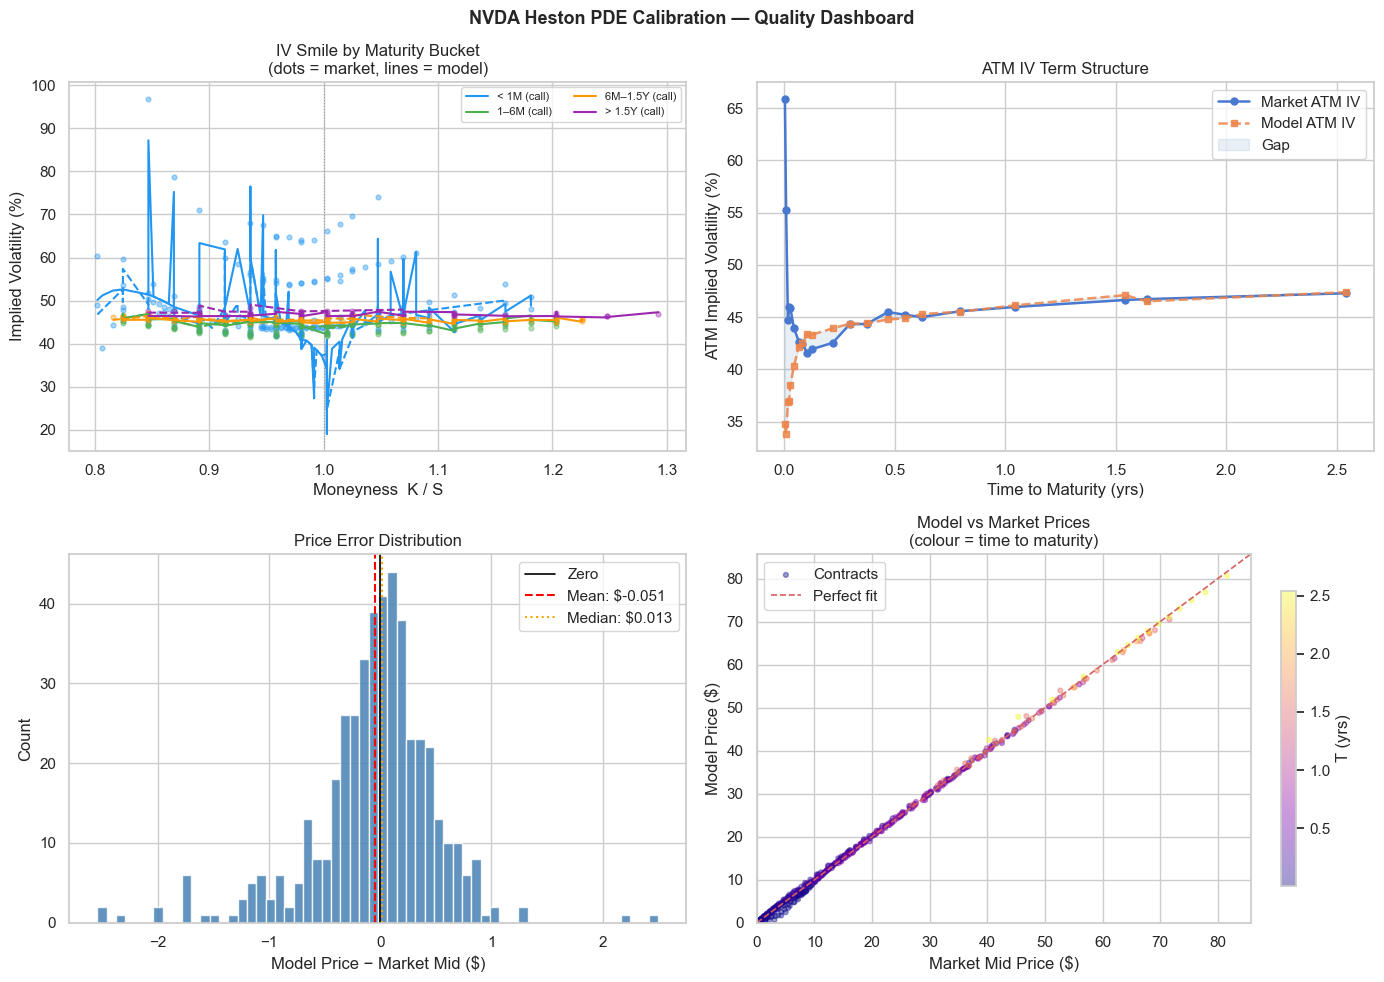

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'NVDA Heston PDE Calibration — Quality Dashboard', fontweight='bold', fontsize=13)

# ── 1. IV smile by maturity bucket ───────────────────────────────────────
ax = axes[0, 0]
T_buckets = [
    (0,    0.1,  '< 1M',     '#2196F3'),
    (0.1,  0.5,  '1–6M',     '#4CAF50'),
    (0.5,  1.5,  '6M–1.5Y',  '#FF9800'),
    (1.5,  5.0,  '> 1.5Y',   '#9C27B0'),
]
for T_lo, T_hi, label, color in T_buckets:
    sub = df[(df['T'] >= T_lo) & (df['T'] < T_hi) & df['market_iv'].notna() & df['model_iv'].notna()]
    if sub.empty:
        continue
    ax.scatter(sub['moneyness'], sub['market_iv'] * 100, s=12, alpha=0.4, color=color)
    for mtype, ls in [('call', '-'), ('put', '--')]:
        s2 = sub[sub['type'] == mtype].sort_values('moneyness')
        if not s2.empty:
            ax.plot(s2['moneyness'], s2['model_iv'] * 100, ls=ls, color=color,
                    lw=1.5, label=f'{label} ({mtype})' if ls == '-' else None)
ax.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Moneyness  K / S')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('IV Smile by Maturity Bucket\n(dots = market, lines = model)')
ax.legend(fontsize=8, ncol=2)

# ── 2. ATM IV term structure ─────────────────────────────────────────────
ax = axes[0, 1]
atm = df[df['atm_distance'] < 0.03].copy()
atm_mkt = atm.groupby('T')['market_iv'].mean() * 100
atm_mdl = atm.groupby('T')['model_iv'].mean()  * 100
ax.plot(atm_mkt.index, atm_mkt.values, 'o-',  lw=1.8, ms=5, label='Market ATM IV')
ax.plot(atm_mdl.index, atm_mdl.values, 's--', lw=1.8, ms=5, label='Model ATM IV',  alpha=0.85)
ax.fill_between(atm_mkt.index, atm_mkt.values,
                atm_mdl.reindex(atm_mkt.index).ffill(),
                alpha=0.12, color='steelblue', label='Gap')
ax.set_xlabel('Time to Maturity (yrs)')
ax.set_ylabel('ATM Implied Volatility (%)')
ax.set_title('ATM IV Term Structure')
ax.legend()

# ── 3. Price error distribution ──────────────────────────────────────────
ax = axes[1, 0]
err = df['price_error'].dropna()
ax.hist(err, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0,           color='black', lw=1.2, ls='-',  label='Zero')
ax.axvline(err.mean(),  color='red',   lw=1.5, ls='--', label=f'Mean: ${err.mean():.3f}')
ax.axvline(err.median(),color='orange',lw=1.5, ls=':',  label=f'Median: ${err.median():.3f}')
ax.set_xlabel('Model Price − Market Mid ($)')
ax.set_ylabel('Count')
ax.set_title('Price Error Distribution')
ax.legend()

# ── 4. Model vs market price scatter ─────────────────────────────────────
ax = axes[1, 1]
scatter = ax.scatter(df['mid_price'], df['model_price'], s=12, alpha=0.4,
                     c=df['T'], cmap='plasma', label='Contracts')
lim = max(df['mid_price'].max(), df['model_price'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.2, label='Perfect fit')
ax.set_xlabel('Market Mid Price ($)')
ax.set_ylabel('Model Price ($)')
ax.set_title('Model vs Market Prices\n(colour = time to maturity)')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.colorbar(scatter, ax=ax, label='T (yrs)', shrink=0.8)
ax.legend()

plt.tight_layout()
#plt.savefig('calibration_quality.png', dpi=120, bbox_inches='tight')
plt.show()


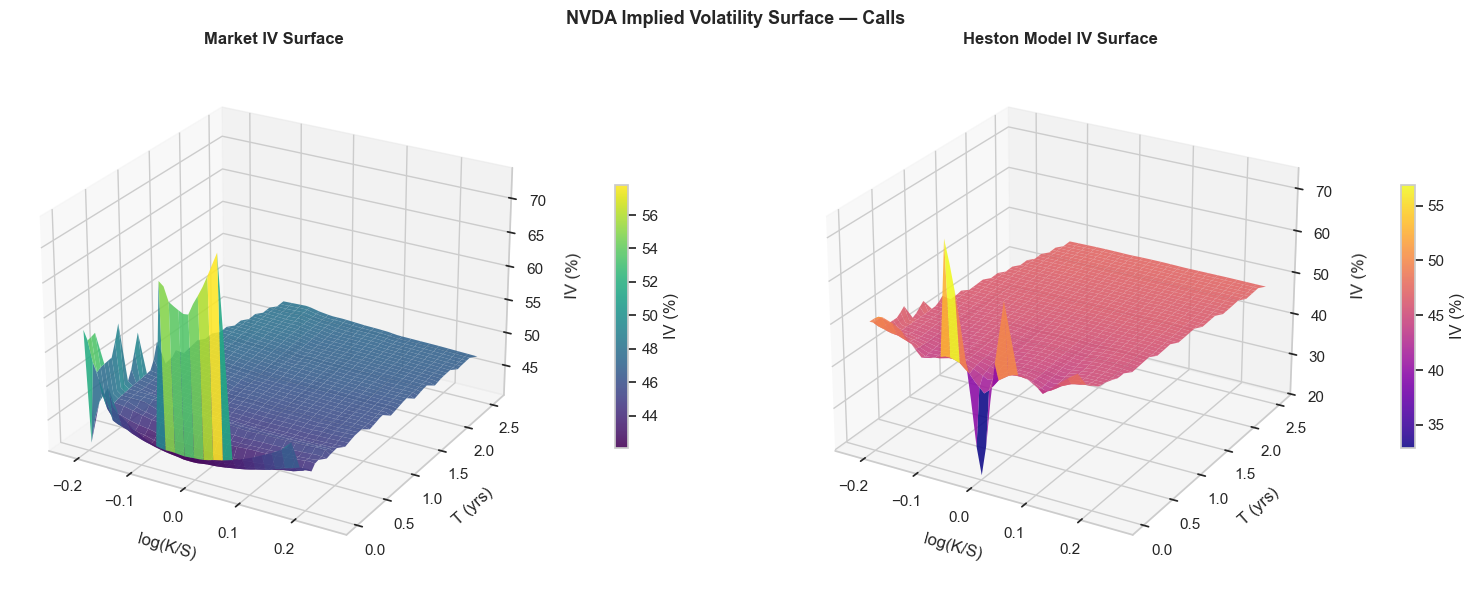

In [75]:
# ── IV Surface (Market vs Model) ─────────────────────────────────────────
surf = df[(df['type'] == 'call') & df['market_iv'].notna() & df['model_iv'].notna()
          & (df['market_iv'] > 0.05)].copy()
surf['log_m'] = np.log(surf['moneyness'])

lm_grid = np.linspace(surf['log_m'].min(), surf['log_m'].max(), 55)
T_grid  = np.linspace(surf['T'].min(),     surf['T'].max(),     45)
LM, TT  = np.meshgrid(lm_grid, T_grid)

Z_mkt = griddata((surf['log_m'], surf['T']), surf['market_iv'] * 100, (LM, TT), method='linear')
Z_mdl = griddata((surf['log_m'], surf['T']), surf['model_iv']  * 100, (LM, TT), method='linear')

fig = plt.figure(figsize=(16, 6))
fig.suptitle('NVDA Implied Volatility Surface — Calls', fontweight='bold', fontsize=13)

for idx, (Z, title, cmap) in enumerate([
    (Z_mkt, 'Market IV Surface',       'viridis'),
    (Z_mdl, 'Heston Model IV Surface', 'plasma'),
], 1):
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    surf_plot = ax.plot_surface(LM, TT, Z, cmap=cmap, alpha=0.88,
                                 linewidth=0, antialiased=True)
    ax.set_xlabel('log(K/S)',  labelpad=8)
    ax.set_ylabel('T (yrs)',   labelpad=8)
    ax.set_zlabel('IV (%)',    labelpad=8)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(surf_plot, ax=ax, shrink=0.5, pad=0.1, label='IV (%)')
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
#plt.savefig('iv_surface.png', dpi=120, bbox_inches='tight')
plt.show()

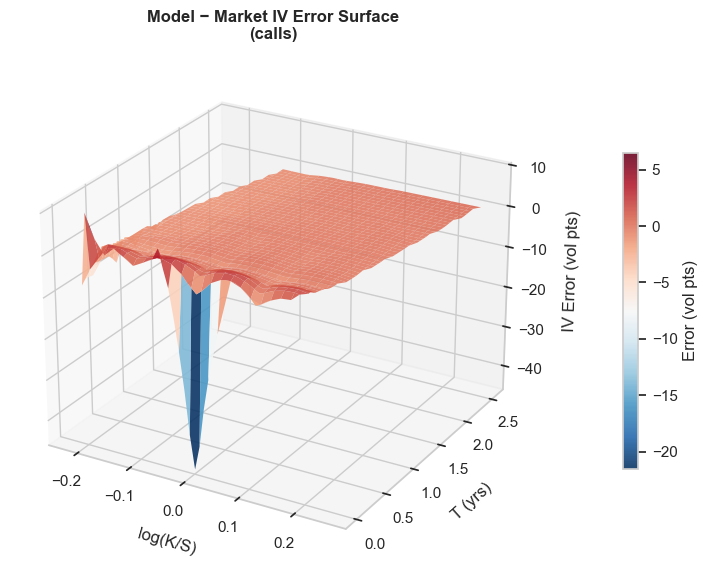

In [76]:
# ── IV Error Surface ──────────────────────────────────────────────────────
Z_err = Z_mdl - Z_mkt

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection='3d')
surf_plot = ax.plot_surface(LM, TT, Z_err, cmap='RdBu_r', alpha=0.88,
                             linewidth=0, antialiased=True)
ax.set_xlabel('log(K/S)', labelpad=8)
ax.set_ylabel('T (yrs)',  labelpad=8)
ax.set_zlabel('IV Error (vol pts)', labelpad=8)
ax.set_title('Model − Market IV Error Surface\n(calls)', fontweight='bold')
plt.colorbar(surf_plot, ax=ax, shrink=0.6, pad=0.1, label='Error (vol pts)')
ax.view_init(elev=25, azim=-60)

plt.tight_layout()
#plt.savefig('iv_error_surface.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 8 — Put-Call Parity Check

For American options the modified parity inequality holds: `C − P ≤ S·e^{−qT} − K·e^{−rT}`.  
We check the **model** call-put difference and compare to the European lower bound.  
Large systematic deviations signal a model consistency issue.

In [77]:
results = []
for mat, grp in df.groupby('maturity'):
    calls = grp[grp['type'] == 'call'].drop_duplicates('strike').set_index('strike')
    puts  = grp[grp['type'] == 'put'].drop_duplicates('strike').set_index('strike')
    common = calls.index.intersection(puts.index)
    if common.empty:
        continue
    par = pd.DataFrame({
        'maturity'  : mat,
        'call_price': calls.loc[common, 'model_price'],
        'put_price' : puts.loc[common,  'model_price'],
        'spot'      : calls.loc[common, 'spot'],
        'T'         : calls.loc[common, 'T'],
        'r_t'       : calls.loc[common, 'r'],
        'q_t'       : calls.loc[common, 'q'],
    })
    par['lhs']          = par['call_price'] - par['put_price']
    par['rhs']          = par['spot'] * np.exp(-par['q_t'] * par['T']) - common * np.exp(-par['r_t'] * par['T'])
    par['parity_error'] = par['lhs'] - par['rhs']
    results.append(par)

parity = pd.concat(results)
print('Put-Call Parity  (model prices, per-row maturity-matched r and q):')
print(parity[['lhs', 'rhs', 'parity_error']].describe().round(4))
print(f'\nMean parity error : {parity["parity_error"].mean():.4f}')
print(f'Std  parity error : {parity["parity_error"].std():.4f}')
print(f'Max |parity error|: {parity["parity_error"].abs().max():.4f}')


Put-Call Parity  (model prices, per-row maturity-matched r and q):
           lhs      rhs  parity_error
count 129.0000 129.0000      129.0000
mean   14.9701  15.1478       -0.1777
std    14.1027  14.1518        0.3606
min   -35.4825 -35.4216       -2.0076
25%     4.9426   5.4609       -0.1535
50%    13.7312  14.0013       -0.0160
75%    25.1091  25.6966       -0.0007
max    43.1832  43.7662        0.0067

Mean parity error : -0.1777
Std  parity error : 0.3606
Max |parity error|: 2.0076


---
## Step 9 — Mispricing Analysis

Contracts where the Heston model price diverges significantly from the market mid-price.  
Large positive errors (model > market) → model sees these as cheap relative to its parameters.  
Large negative errors (market > model) → model sees these as expensive.

In [78]:
df['mispricing_$']   = df['model_price'] - df['mid_price']
df['mispricing_%']   = df['mispricing_$'] / df['mid_price'] * 100

SHOW_COLS = ['type', 'maturity', 'strike', 'T', 'mid_price', 'model_price',
             'mispricing_$', 'mispricing_%', 'market_iv', 'model_iv']

print('Top 10 — Model OVER-PRICED  (model > market, potential market buys)')
print('─' * 110)
over = df.nlargest(10, 'mispricing_$')[SHOW_COLS]
print(over.to_string(index=False))

print()
print('Top 10 — Model UNDER-PRICED (market > model, potential market sells)')
print('─' * 110)
under = df.nsmallest(10, 'mispricing_$')[SHOW_COLS]
print(under.to_string(index=False))

Top 10 — Model OVER-PRICED  (model > market, potential market buys)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
type   maturity   strike      T  mid_price  model_price  mispricing_$  mispricing_%  market_iv  model_iv
 put 2028-12-15 210.0000 2.5402    45.3750      47.8761        2.5011        5.5121     0.4697    0.4908
 put 2028-12-15 200.0000 2.5402    40.3000      42.5029        2.2029        5.4663     0.4690    0.4884
 put 2027-12-17 240.0000 1.5429    52.6750      53.9830        1.3080        2.4832     0.4669    0.4792
 put 2027-12-17 230.0000 1.5429    46.7750      48.0203        1.2453        2.6624     0.4652    0.4772
 put 2028-01-21 210.0000 1.6388    37.2000      38.2236        1.0236        2.7516     0.4656    0.4759
 put 2027-12-17 220.0000 1.5429    41.3250      42.3266        1.0016        2.4236     0.4651    0.4751
 put 2026-08-21 215.0000 0.2196    12.4000      13.3341        0.9341        7.5332   

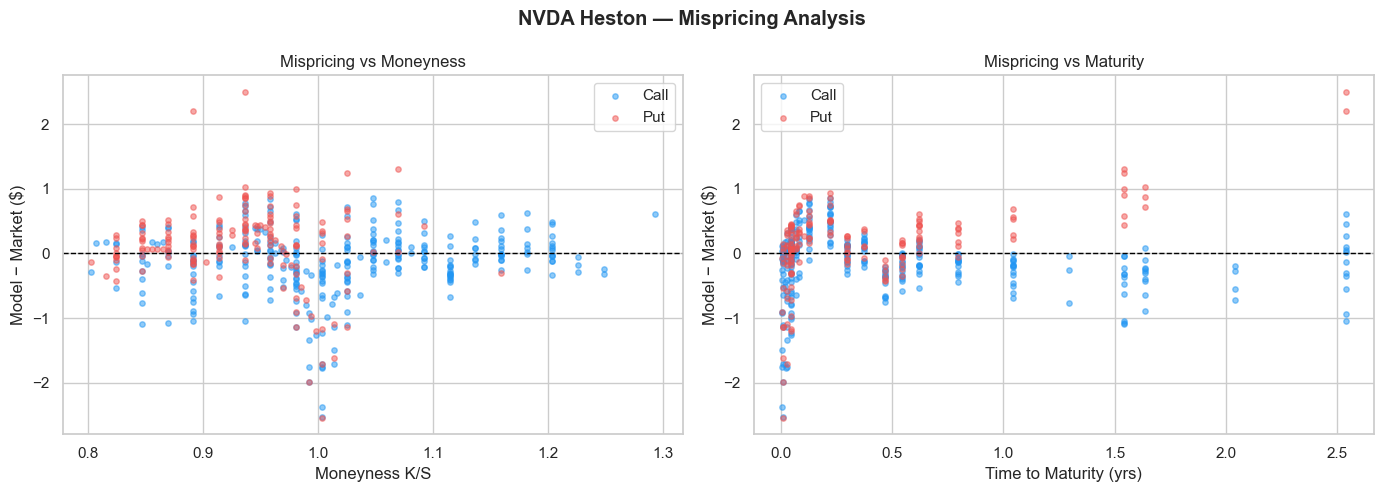

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NVDA Heston — Mispricing Analysis', fontweight='bold')

# Mispricing vs moneyness (calls and puts)
ax = axes[0]
for mtype, color in [('call', '#2196F3'), ('put', '#EF5350')]:
    sub = df[df['type'] == mtype]
    ax.scatter(sub['moneyness'], sub['mispricing_$'], s=15, alpha=0.5,
               color=color, label=mtype.capitalize())
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Model − Market ($)')
ax.set_title('Mispricing vs Moneyness')
ax.legend()

# Mispricing vs maturity
ax = axes[1]
for mtype, color in [('call', '#2196F3'), ('put', '#EF5350')]:
    sub = df[df['type'] == mtype]
    ax.scatter(sub['T'], sub['mispricing_$'], s=15, alpha=0.5,
               color=color, label=mtype.capitalize())
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Time to Maturity (yrs)')
ax.set_ylabel('Model − Market ($)')
ax.set_title('Mispricing vs Maturity')
ax.legend()

plt.tight_layout()
#plt.savefig('mispricing.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Summary

In [80]:
print('=' * 60)
print('  NVDA HESTON PRICING ENGINE — PIPELINE SUMMARY')
print('=' * 60)
print()
print(f'  Market data')
print(f'    Ticker               : {TICKER}')
print(f'    Instrument / exercise: {INSTRUMENT_TYPE} / {EXERCISE_STYLE.capitalize()}')
print(f'    Spot                 : ${SPOT:.2f}')
q_filt = filtered_df['q']
print(f'    Dividend yield q     : {q_filt.min()*100:.4f}% – {q_filt.max()*100:.4f}%  '
      f'(median {q_filt.median()*100:.4f}%, per-row in df["q"])')
if 'dividend_source' in filtered_df.columns:
    src_mix = ', '.join(f'{k}×{v}' for k, v in filtered_df['dividend_source'].value_counts().items())
    print(f'    Dividend source      : {src_mix}  (implied forward via put-call parity / trailing fallback)')
print()
print(f'  Interest rate')
print(f'    Methodology          : Per-row maturity-matched SOFR/OIS (df["r"])')
print(f'    3M SOFR (scalar R)   : {R*100:.3f}%  (display/fallback only)')
print(f'    Curve                : {curve_summary(rate_curve)}')
print(f'    r range in df        : {filtered_df["r"].min()*100:.3f}% – {filtered_df["r"].max()*100:.3f}%')
print()
print(f'  Filtering')
print(f'    Raw contracts        : {n_raw:,}')
print(f'    After filters        : {n_filt:,}  ({n_filt/n_raw*100:.1f}%)')
print(f'    Expiries             : {filtered_df["maturity"].nunique()}')
print()
print(f'  Calibration  (PDE / C++ MCS ADI)')
print(f'    v₀                   : {p.v0:.6f}  → init vol {p.v0**0.5*100:.1f}%')
print(f'    κ  (mean reversion)  : {p.kappa:.4f}')
print(f'    θ̄  (long-run var)    : {p.theta:.6f}  → LR vol {p.theta**0.5*100:.1f}%')
print(f'    σ  (vol of vol)      : {p.sigma:.4f}')
print(f'    ρ  (spot-vol corr)   : {p.rho:.4f}')
print(f'    Feller 2κθ−σ²        : {feller:+.4f}  ({"satisfied ✓" if feller > 0 else "VIOLATED ✗"})')
print(f'    Loss                 : {res_pde.loss:.4e}')
print(f'    Runtime              : {res_pde.runtime_seconds:.1f}s')
print()
print(f'  Pricing accuracy')
print(f'    MAE                  : ${df["abs_error"].mean():.4f}')
print(f'    Mean rel error       : {df["rel_error"].abs().mean()*100:.2f}%')
print(f'    Within bid-ask       : {df["within_spread"].sum()} / {len(df)}  ({df["within_spread"].mean()*100:.1f}%)')
print(f'    Mean IV error        : {df["iv_error"].abs().mean()*100:.2f} vol pts')
print('=' * 60)


  NVDA HESTON PRICING ENGINE — PIPELINE SUMMARY

  Market data
    Ticker               : NVDA
    Instrument / exercise: EQUITY / American
    Spot                 : $224.36
    Dividend yield q     : 0.1076% – 9.6506%  (median 0.6166%, per-row in df["q"])
    Dividend source      : implied_forward×460  (implied forward via put-call parity / trailing fallback)

  Interest rate
    Methodology          : Per-row maturity-matched SOFR/OIS (df["r"])
    3M SOFR (scalar R)   : 3.642%  (display/fallback only)
    Curve                : 3M: 3.64%  |  6M: 3.69%  |  5Y: 4.19%  |  10Y: 4.47%
    r range in df        : 3.591% – 4.134%

  Filtering
    Raw contracts        : 4,253
    After filters        : 460  (10.8%)
    Expiries             : 23

  Calibration  (PDE / C++ MCS ADI)
    v₀                   : 0.200991  → init vol 44.8%
    κ  (mean reversion)  : 6.5350
    θ̄  (long-run var)    : 0.210690  → LR vol 45.9%
    σ  (vol of vol)      : 1.0000
    ρ  (spot-vol corr)   : -0.0338
    